In [1]:

!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.2 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import torchmetrics
import scipy
from skimage.transform import radon, resize, iradon
import skimage

In [3]:
device = torch.device('cuda')

In [4]:
def grayscale(image):
    weights = [0.299, 0.587, 0.114]
    return np.dot(image[...,:3], weights)

def create_image(csf,wht,gry, alpha=5, sigma=100):
    csf = grayscale(csf)
    wht = grayscale(wht)
    gry = grayscale(gry)
    shape = csf.shape
    dx = np.random.randn(shape[0], shape[1])
    dy = np.random.randn(shape[0], shape[1])
    dx = scipy.ndimage.gaussian_filter(dx, sigma) * alpha
    dy = scipy.ndimage.gaussian_filter(dy, sigma) * alpha
    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    indices_x = x + dx
    indices_y = y + dy
    deformed_csf = scipy.ndimage.map_coordinates(csf, [indices_y, indices_x], order=5, mode='reflect')
    deformed_wht = scipy.ndimage.map_coordinates(wht, [indices_y, indices_x], order=5, mode='reflect')
    deformed_gry = scipy.ndimage.map_coordinates(gry, [indices_y, indices_x], order=5, mode='reflect')
    angle = np.random.uniform(-5, 5)
    deformed_image = scipy.ndimage.rotate(deformed_csf, angle, reshape=False, order=5, mode='reflect')
    deformed_wht = scipy.ndimage.rotate(deformed_wht, angle, reshape=False, order=5, mode='reflect')
    deformed_gry = scipy.ndimage.rotate(deformed_gry, angle, reshape=False, order=5, mode='reflect')
    scale = np.random.uniform(0.9, 1.1)
    deformed_csf = scipy.ndimage.zoom(deformed_csf, scale, order=5)
    deformed_wht = scipy.ndimage.zoom(deformed_wht, scale, order=5)
    deformed_gry = scipy.ndimage.zoom(deformed_gry, scale, order=5)
    deformed_image = np.random.normal(0.1, 0.025) * deformed_csf + np.random.normal(0.4, 0.025) * deformed_gry + np.random.normal(0.25, 0.025) * deformed_wht
    if scale > 1.0:
        start = (deformed_image.shape[0] - shape[0]) // 2
        deformed_image = deformed_image[start:start+shape[0], start:start+shape[1]]
    else:
        pad_width = (shape[0] - deformed_image.shape[0]) // 2
        deformed_image = np.pad(deformed_image, pad_width, mode='reflect')
        deformed_image = deformed_image[:shape[0], :shape[1]]
    deformed_image = deformed_image[:128,:128]
    deformed_image -= np.min(deformed_image)
    deformed_image /= np.max(deformed_image)
    return deformed_image


In [5]:
def create_tumor_image(csf,wht,gry, alpha=5, sigma=100):
    csf = grayscale(csf)
    wht = grayscale(wht)
    gry = grayscale(gry)
    shape = csf.shape
    dx = np.random.randn(shape[0], shape[1])
    dy = np.random.randn(shape[0], shape[1])
    dx = scipy.ndimage.gaussian_filter(dx, sigma) * alpha
    dy = scipy.ndimage.gaussian_filter(dy, sigma) * alpha
    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    mu_x = np.clip(np.random.randn() + 0.5, 0.35, 0.65)
    mu_y = np.clip(np.random.randn() + 0.5, 0.35, 0.65)
    size = np.random.randn()* 0.32 + 1.5
    tumor = np.exp(-((x - mu_x * shape[1]) ** 2 + (y - mu_y * shape[0]) ** 2) / (2 * size ** 2))
    indices_x = x + dx
    indices_y = y + dy
    deformed_csf = scipy.ndimage.map_coordinates(csf, [indices_y, indices_x], order=5, mode='reflect')
    deformed_wht = scipy.ndimage.map_coordinates(wht, [indices_y, indices_x], order=5, mode='reflect')
    deformed_gry = scipy.ndimage.map_coordinates(gry, [indices_y, indices_x], order=5, mode='reflect')
    deformed_tum = scipy.ndimage.map_coordinates(tumor, [indices_y, indices_x], order=5, mode='reflect')
    angle = np.random.uniform(-5, 5)
    deformed_image = scipy.ndimage.rotate(deformed_csf, angle, reshape=False, order=5, mode='reflect')
    deformed_wht = scipy.ndimage.rotate(deformed_wht, angle, reshape=False, order=5, mode='reflect')
    deformed_gry = scipy.ndimage.rotate(deformed_gry, angle, reshape=False, order=5, mode='reflect')
    deformed_tum = scipy.ndimage.rotate(deformed_tum, angle, reshape=False, order=5, mode='reflect')
    scale = np.random.uniform(0.9, 1.1)
    deformed_csf = scipy.ndimage.zoom(deformed_csf, scale, order=5)
    deformed_wht = scipy.ndimage.zoom(deformed_wht, scale, order=5)
    deformed_gry = scipy.ndimage.zoom(deformed_gry, scale, order=5)
    deformed_tum = scipy.ndimage.zoom(deformed_tum, scale, order=5)
    deformed_image = np.random.normal(0.1, 0.025) * deformed_csf + np.random.normal(0.4, 0.025) * deformed_gry + np.random.normal(0.25, 0.025) * deformed_wht
    if scale > 1.0:
        start = (deformed_image.shape[0] - shape[0]) // 2
        deformed_image = deformed_image[start:start+shape[0], start:start+shape[1]]
        deformed_tum = deformed_tum[start:start+shape[0], start:start+shape[1]]
    else:
        pad_width = (shape[0] - deformed_image.shape[0]) // 2
        deformed_image = np.pad(deformed_image, pad_width, mode='reflect')
        deformed_image = deformed_image[:shape[0], :shape[1]]
        deformed_tum = np.pad(deformed_tum, pad_width, mode='reflect')
        deformed_tum = deformed_tum[:shape[0], :shape[1]]
    deformed_tum = deformed_tum[:128,:128]
    deformed_tum -= np.min(deformed_tum)
    deformed_tum /= np.max(deformed_tum)
    deformed_tum[deformed_tum < 0.2] = 0
    deformed_image = deformed_image[:128,:128]
    deformed_image -= np.min(deformed_image)
    deformed_image /= np.max(deformed_image)

    return deformed_image, deformed_tum

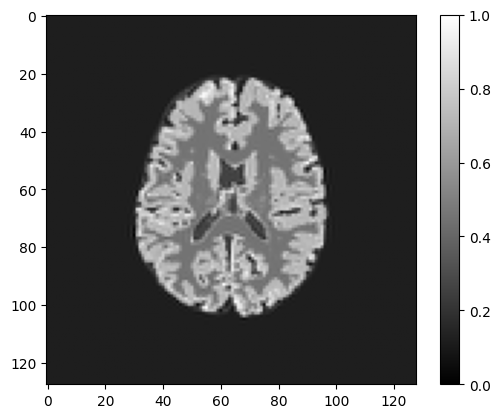

In [5]:
csf = plt.imread('1_csf.gif')
wht = plt.imread('1_wht.gif')
gry = plt.imread('1_gry.gif')

plt.imshow(create_image(csf,wht,gry), cmap='gray')
plt.colorbar()

100%|██████████| 20/20 [02:58<00:00,  8.93s/it]


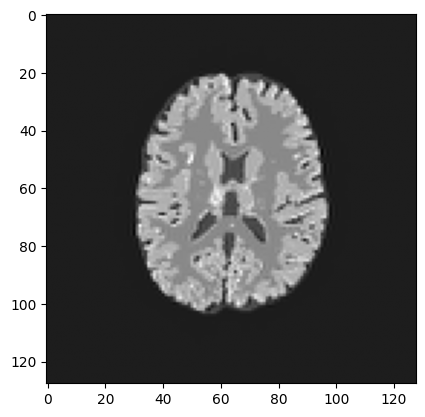

In [6]:
images = []
for i in tqdm.tqdm(range(1,21)):
    csf = plt.imread(f'{i}_csf.gif')
    gry = plt.imread(f'{i}_gry.gif')
    wht = plt.imread(f'{i}_wht.gif')
    for _ in range(100):
        images.append(create_image(csf,wht,gry))
plt.imshow(images[-1], cmap='gray')
plt.show()

In [7]:
images = np.array(images)
images = torch.tensor(images, dtype=torch.float32)
images = images.unsqueeze(1)
dataset = torch.utils.data.TensorDataset(images)
loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

In [8]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim = 64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )
        self.fc_encode = nn.Linear(256*8*8, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 256*8*8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        z = self.encoder(x)
        z = z.view(z.size(0), -1)
        z = self.fc_encode(z)
        return z

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(x.size(0), 256, 8, 8)
        x = self.decoder(x)
        return x

    def forward(self,x):
        z = self.encode(x)
        reconstruction = self.decode(z)
        return reconstruction

class LatentDiscriminator(nn.Module):
    def __init__(self, latent_dim = 64):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

In [9]:
def image_gradient(image):
    dx = image[:,:,:,1:] - image[:,:,:,:-1]
    dy = image[:,:,1:,:] - image[:,:,:-1,:]
    return dx, dy

def gradient_loss(reconstruction, x):
    dx, dy = image_gradient(reconstruction)
    dx_gt, dy_gt = image_gradient(x)
    loss = F.mse_loss(dx, dx_gt) + F.mse_loss(dy, dy_gt)
    return loss

def vae_loss(reconstruction, x, mean, logvar, beta=0.00001):
    mse = F.mse_loss(reconstruction, x)
    kl_loss = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    #structure_loss = 1 - torchmetrics.functional.structural_similarity_index_measure(reconstruction, x)
    grad_loss = gradient_loss(reconstruction, x)
    total_loss = mse + beta * kl_loss  + 0.1 * grad_loss# + 0.1 * structure_loss
    return total_loss#, mse, kl_loss, structure_loss, grad_loss

In [ ]:
ae = AutoEncoder(latent_dim=128).to(device)
disc = LatentDiscriminator(latent_dim=128).to(device)

ae_optimizer = torch.optim.Adam(ae.parameters(), lr = 1e-3)
disc_optimizer = torch.optim.Adam(disc.parameters(), lr = 1e-3)

epochs = 100
ae.train()
for epoch in tqdm.tqdm(range(epochs)):
    total_ae_loss = 0
    for batch in loader:
        x = batch[0].to(device)
        reconstruction = ae(x)
        loss = F.mse_loss(reconstruction, x) + gradient_loss(reconstruction, x) + (1 - torchmetrics.functional.structural_similarity_index_measure(reconstruction, x))
        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()
        total_ae_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_ae_loss/len(loader)}")

  0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(
  1%|          | 1/100 [00:02<03:48,  2.31s/it]

Epoch 1/100, Loss: 0.5940532868816739


  2%|▏         | 2/100 [00:03<02:56,  1.81s/it]

Epoch 2/100, Loss: 0.28074744154536535


  3%|▎         | 3/100 [00:05<02:39,  1.65s/it]

...

Epoch 98/100, Loss: 0.05536165029283554


 99%|█████████▉| 99/100 [02:36<00:01,  1.61s/it]

Epoch 99/100, Loss: 0.0547508629896338


100%|██████████| 100/100 [02:38<00:00,  1.58s/it]

Epoch 100/100, Loss: 0.05450465405980746


/tmp/ipykernel_1087/1985699345.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).unsqueeze(0).to(device)


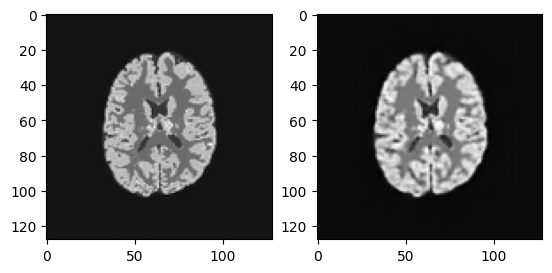

In [ ]:
ae.eval()
with torch.no_grad():
  x = images[np.random.randint(0, len(images))]
  x = torch.tensor(x).unsqueeze(0).to(device)
  recon = ae(x)
  plt.subplot(1,2,1)
  plt.imshow(x.cpu()[0][0], cmap='gray')
  plt.subplot(1,2,2)
  plt.imshow(recon.cpu()[0][0], cmap='gray')



In [ ]:
torch.save(ae.state_dict(), 'ae_pretrained.pth')

In [ ]:
disc = LatentDiscriminator(latent_dim=128).to(device)

aae_optimizer = torch.optim.Adam(ae.parameters(), lr = 1e-4)
disc_optimizer = torch.optim.Adam(disc.parameters(), lr = 1e-4)

aae_epochs = 100
ae.train()
disc.train()


for epoch in tqdm.tqdm(range(epochs)):
  total_rec = 0
  total_adv = 0
  total_disc = 0
  for batch in loader:
    x = batch[0].float().to(device)
    z_real = torch.randn(x.size(0), 128, device=device)
    z_fake = ae.encode(x).detach()

    pred_real = disc(z_real)
    pred_fake = disc(z_fake)

    label_real = torch.ones_like(pred_real)
    label_fake = torch.zeros_like(pred_fake)

    loss_real = F.binary_cross_entropy(pred_real, label_real)
    loss_fake = F.binary_cross_entropy(pred_fake, label_fake)
    disc_loss = loss_real + loss_fake
    disc_optimizer.zero_grad()
    disc_loss.backward()
    disc_optimizer.step()

    for p in disc.parameters():
      p.requires_grad = False
    z = ae.encode(x)
    reconstruction = ae.decode(z)
    rec_loss = F.mse_loss(reconstruction, x) + gradient_loss(reconstruction, x) + (1 - torchmetrics.functional.structural_similarity_index_measure(reconstruction, x))
    pred_fake = disc(z)
    adv_loss = F.binary_cross_entropy(pred_fake, torch.ones_like(pred_fake))
    ae_loss = rec_loss + 0.01 * adv_loss
    aae_optimizer.zero_grad()
    ae_loss.backward()
    aae_optimizer.step()

    for p in disc.parameters():
      p.requires_grad = True

    total_rec += rec_loss.item()
    total_adv += adv_loss.item()
    total_disc += disc_loss.item()

  print(f"Epoch {epoch + 1}, rec_loss {total_rec / len(loader)}, adv_loss {total_adv/len(loader)}, disc_loss {total_disc / len(loader)}")


  0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(
  1%|          | 1/100 [00:01<03:04,  1.86s/it]

Epoch 1, rec_loss 0.0508322799726138, adv_loss 0.7356196481084066, disc_loss 1.2864543615825592


  2%|▏         | 2/100 [00:03<02:53,  1.77s/it]

Epoch 2, rec_loss 0.049740150748264225, adv_loss 0.8651685591727968, disc_loss 1.025147210984003


  3%|▎         | 3/100 [00:05<02:48,  1.74s/it]

...

Epoch 98, rec_loss 0.05727910356862204, adv_loss 1.3733728140119523, disc_loss 0.9471527830002799


 99%|█████████▉| 99/100 [02:58<00:01,  1.80s/it]

Epoch 99, rec_loss 0.056134499077286036, adv_loss 1.1524428772547888, disc_loss 0.9118761354022555


100%|██████████| 100/100 [03:00<00:00,  1.81s/it]

Epoch 100, rec_loss 0.054196536777511475, adv_loss 1.106212578122578, disc_loss 0.7941956274093144


/tmp/ipykernel_1087/1721986319.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).unsqueeze(0).to(device)


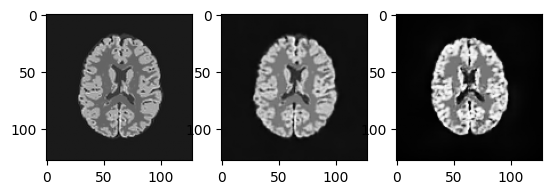

In [ ]:
ae.eval()
disc.eval()
with torch.no_grad():
  x = images[np.random.randint(0, len(images))]
  x = torch.tensor(x).unsqueeze(0).to(device)
  recon = ae(x)
  z = torch.randn(1, 128, device=device)
  gen = ae.decode(z).cpu()
  plt.subplot(1,3,1)
  plt.imshow(x.cpu()[0][0], cmap='gray')
  plt.subplot(1,3,2)
  plt.imshow(recon.cpu()[0][0], cmap='gray')
  plt.subplot(1,3,3)
  plt.imshow(gen[0][0], cmap='gray')

In [ ]:
torch.save(ae.state_dict(), 'ae_trained.pth')
torch.save(disc.state_dict(), 'disc_trained.pth')

In [ ]:
with torch.no_grad():
  n = np.random.randint(1,21)
  csf = plt.imread(f'{n}_csf.gif')
  gry = plt.imread(f'{n}_gry.gif')
  wht = plt.imread(f'{n}_wht.gif')
  src_img = plt.imread(f'{n}')

In [10]:
!pip install git+https://github.com/matteo-ronchetti/torch-radon.git

  Cloning https://github.com/matteo-ronchetti/torch-radon.git to /tmp/pip-req-build-jexu4eub
  Running command git clone --filter=blob:none --quiet https://github.com/matteo-ronchetti/torch-radon.git /tmp/pip-req-build-jexu4eub
  Resolved https://github.com/matteo-ronchetti/torch-radon.git to commit 5796b2a07e3bb0a248430e9a07fb48db5994d4ea
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.1 MB/s eta 0:00:00
  Created wheel for torch_radon: filename=torch_radon-1.0.0-cp312-cp312-linux_x86_64.whl size=2591806 sha256=aadcd4e5dacd63c700a086b61e66384fe8ebe153e466bd428eb69e8c713f3651
  Stored in directory: /tmp/pip-ephem-wheel-cache-pofbs281/wheels/44/bd/e0/82bd3123fc0a1530b72979acb2125f6b7026db6cdb6b9f10f8
Successfully built torch_radon


In [11]:
from torch_radon import Radon

In [12]:
angles = torch.linspace(0, torch.pi, 361)[:-1]
radon_operator = Radon(resolution = 128, angles = angles, det_count=182, clip_to_circle=False)

def forward_project_torch(image):
  image = image[:, 0]
  sinogram = radon_operator.forward(image)
  return sinogram

In [13]:
ae_state_dict = torch.load('ae_trained.pth', map_location=device)
#disc_state_dict = torch.load('disc_trained.pth', map_location=device)
trained_ae = AutoEncoder(latent_dim=128)
trained_ae.load_state_dict(ae_state_dict)
#trained_disc = LatentDiscriminator(latent_dim=128)
#trained_disc.load_state_dict(disc_state_dict)
trained_ae = trained_ae.to(device)

In [14]:
from sklearn.decomposition import PCA

latents = []
with torch.no_grad():
    for batch in loader:
        x = batch[0].float().to(device)
        z = trained_ae.encode(x)
        latents.append(z)
z = torch.cat(latents, dim=0).cpu().numpy()

pca = PCA(n_components = 40)
z_pca = pca.fit_transform(z)

In [15]:
def forward_project(image, I0 = 1e4):
    angles = np.linspace(0., 180., 360, endpoint=False)
    sinogram = radon(image, theta=angles, circle=False)
    expected_counts = I0 * np.exp(-0.02 * sinogram)
    measured_counts = np.random.poisson(expected_counts) + np.random.normal(0, 100, expected_counts.shape)
    measured_counts[measured_counts <= 0] = 1
    #noisy_sinogram = -np.log(measured_counts/I0)
    return measured_counts

im, tum = create_tumor_image(csf,wht,gry)
tum_im = im + tum

In [ ]:
forward_project(tum_im).shape

(182, 360)

In [18]:
pca_mean = torch.tensor(pca.mean_, dtype=torch.float32, device=device)
pca_components = torch.tensor(pca.components_, dtype=torch.float32, device=device)

def decode_pca(c):
    z = pca_mean + pca_components.T @ c
    recon = trained_ae.decode(z.unsqueeze(0))
    return recon

def forward_model(c, res):
    x = decode_pca(c) + res
    x = torch.clamp(x, min=0.0)
    Ax = forward_project_torch(x)
    return 0.02 * Ax

def poisson_loss(Ax, y, I0 = 5e3):
    eps = 1e-8
    expected = I0 * torch.exp(-Ax)
    #return (expected - y + y * torch.log((y + eps) / (expected + eps))).mean()
    return (expected - y * torch.log(expected + eps)).mean()

def highfreq_reg(r):
    kernel = torch.tensor([
        [0,-1,0],
        [-1,4,-1],
        [0,-1,0]
    ], dtype=torch.float32, device=device).view(1,1,3,3)
    laplacian_pen = torch.sum(torch.conv2d(r,kernel, padding=1) ** 2)
    return laplacian_pen

def manifold_reg(c):
    return torch.sum(c ** 2)

def objective(c, r, y, lam_r = 0.001, lam_f = 0.005, lam_c = 0.005):
    Ax = forward_model(c, r)
    data_validity = poisson_loss(Ax, y)
    sparsity = lam_r * torch.abs(r).sum()
    laplacian_pen = lam_f * highfreq_reg(r)
    manifold_pen = lam_c * manifold_reg(c)
    return data_validity + sparsity + laplacian_pen + manifold_pen

y_measured = forward_project(tum_im, I0 = 5e3)
fbp_recon = iradon(-np.log(y_measured / 5e3 + 1e-8) / 0.02,theta=np.linspace(0,180,360,endpoint=False),circle=False, filter_name='hamming')
y_measured = torch.tensor(y_measured.T, dtype=torch.float32, device=device).unsqueeze(0)

fbp_recon = torch.tensor(fbp_recon, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
with torch.no_grad():
  z_fbp = trained_ae.encode(fbp_recon)
c = pca.transform(z_fbp.detach().cpu().numpy())
c = torch.tensor(c[0], dtype=torch.float32, device=device, requires_grad=True)
#c = torch.zeros(pca_components.shape[0], requires_grad=True, device=device)
r = torch.zeros((1,1,128,128), requires_grad=True, device=device)

opt_c = torch.optim.Adam([c], lr = 1e-3)
opt_r = torch.optim.Adam([r], lr = 1e-4)

In [14]:
device = torch.device('cuda')

In [ ]:
from IPython.display import clear_output

  1%|          | 1/100 [00:00<01:35,  1.04it/s]

Global Epoch: 0, Loss: -25258.068359375


  2%|▏         | 2/100 [00:01<01:14,  1.32it/s]

Global Epoch: 1, Loss: -25258.21484375


  3%|▎         | 3/100 [00:02<01:08,  1.41it/s]

...

Global Epoch: 97, Loss: -25258.70703125


 99%|█████████▉| 99/100 [00:41<00:00,  2.53it/s]

Global Epoch: 98, Loss: -25258.705078125


100%|██████████| 100/100 [00:41<00:00,  2.41it/s]

Global Epoch: 99, Loss: -25258.70703125


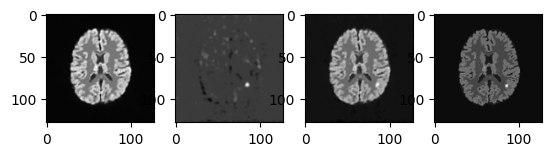

In [ ]:

global_epochs = 100
inner_epochs = 50


for g_epoch in tqdm.tqdm(range(global_epochs)):

    for _ in range(inner_epochs):
        opt_c.zero_grad()
        loss = objective(c,r,y_measured)
        loss.backward()
        opt_c.step()



    for _ in range(inner_epochs):
        opt_r.zero_grad()
        loss = objective(c,r,y_measured)
        loss.backward()
        opt_r.step()

        '''with torch.no_grad():
            threshold = 1e-2
            r.data = torch.sign(r.data) * torch.clamp(torch.abs(r.data) - threshold, min=0)'''
    print(f'Global Epoch: {g_epoch}, Loss: {loss.item()}')

with torch.no_grad():
    plt.subplot(1,4,1)
    plt.imshow(decode_pca(c)[0][0].detach().cpu().numpy(), cmap='gray')
    plt.subplot(1,4,2)
    plt.imshow(r[0][0].detach().cpu().numpy(), cmap='gray')
    plt.subplot(1,4,3)
    plt.imshow(decode_pca(c)[0][0].detach().cpu().numpy() + r[0][0].detach().cpu().numpy(), cmap='gray')
    plt.subplot(1,4,4)
    plt.imshow(tum_im, cmap='gray')




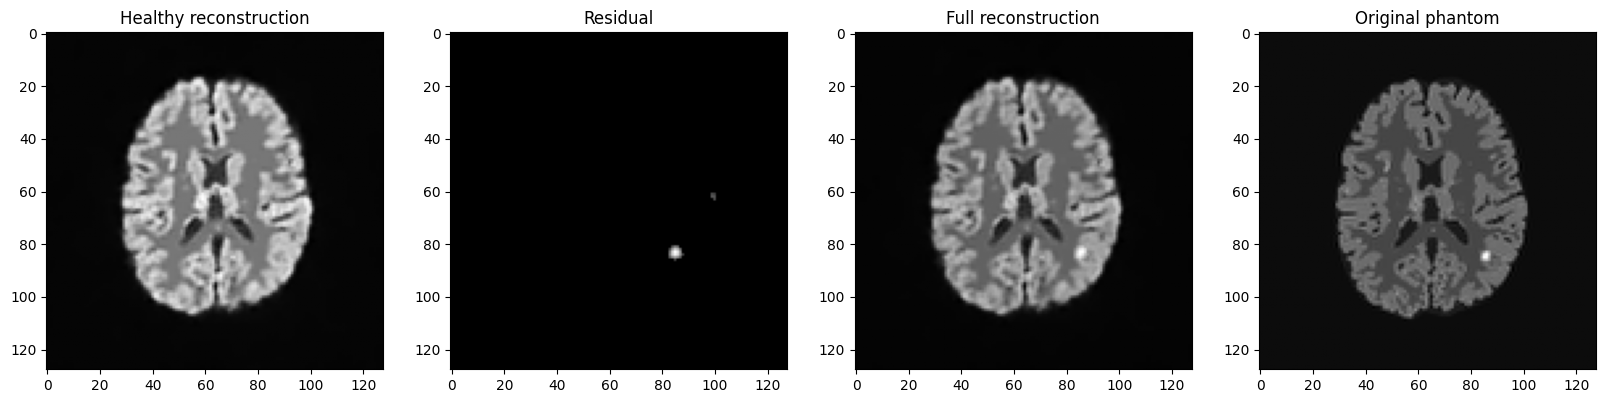

In [ ]:
post_r = r[0][0].detach().cpu().numpy().copy()
post_r[post_r < 0.1] = 0
healthy_recon = decode_pca(c)[0][0].detach().cpu().numpy().copy()
with torch.no_grad():
    plt.figure(figsize = (20,5))
    plt.subplot(1,4,1)
    plt.imshow(healthy_recon, cmap='gray')
    plt.title('Healthy reconstruction')
    plt.subplot(1,4,2)
    plt.imshow(post_r, cmap='gray')
    plt.title('Residual')
    plt.subplot(1,4,3)
    plt.imshow(healthy_recon + post_r, cmap='gray')
    plt.title('Full reconstruction')
    plt.subplot(1,4,4)
    plt.imshow(tum_im, cmap='gray')
    plt.title('Original phantom')

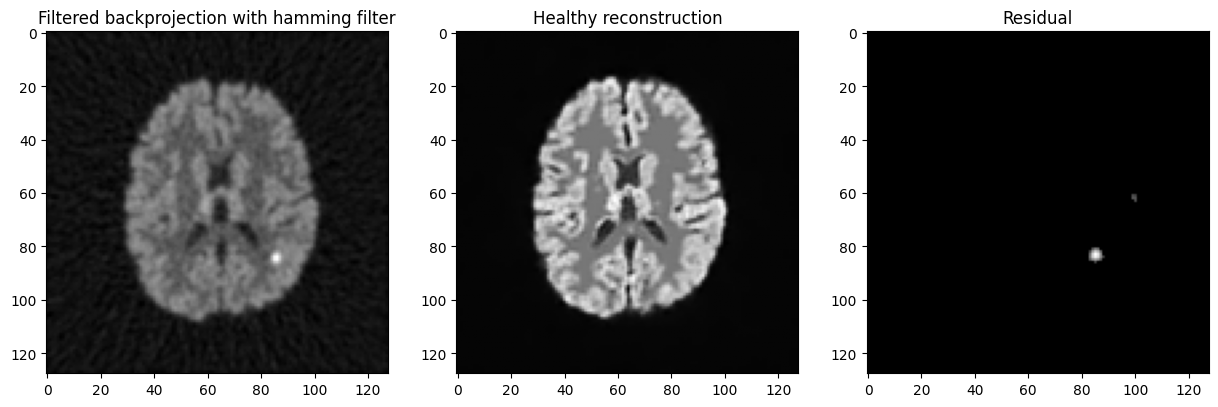

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title('Filtered backprojection with hamming filter')
plt.imshow(fbp_recon.cpu()[0][0], cmap='gray')
plt.subplot(1,3,2)
plt.title('Healthy reconstruction')
plt.imshow(healthy_recon, cmap='gray')
plt.subplot(1,3,3)
plt.title('Residual')
plt.imshow(post_r,cmap='gray')

In [255]:
pca_mean = torch.tensor(pca.mean_, dtype=torch.float32, device=device)
pca_components = torch.tensor(pca.components_, dtype=torch.float32, device=device)

def decode_pca(c):
    z = pca_mean + pca_components.T @ c
    recon = trained_ae.decode(z.unsqueeze(0))
    return recon

def forward_model(c, res):
    x = decode_pca(c) + res
    x = torch.clamp(x, min=0.0)
    Ax = forward_project_torch(x)
    return 0.02 * Ax

def poisson_loss(Ax, y, I0 = 1e3):
    eps = 1e-8
    expected = I0 * torch.exp(-Ax)
    #return (expected - y + y * torch.log((y + eps) / (expected + eps))).mean()
    return (expected - y * torch.log(expected + eps)).mean()

def highfreq_reg(r):
    kernel = torch.tensor([
        [0,-1,0],
        [-1,4,-1],
        [0,-1,0]
    ], dtype=torch.float32, device=device).view(1,1,3,3)
    laplacian_pen = torch.sum(torch.conv2d(r,kernel, padding=1) ** 2)
    return laplacian_pen

def manifold_reg(c):
    return torch.sum(c ** 2)

def objective(c, r, y, lam_r = 0.001, lam_f = 0.005, lam_c = 0.005):
    Ax = forward_model(c, r)
    data_validity = poisson_loss(Ax, y)
    sparsity = lam_r * torch.abs(r).sum()
    laplacian_pen = lam_f * highfreq_reg(r)
    manifold_pen = lam_c * manifold_reg(c)
    return data_validity + sparsity + laplacian_pen + manifold_pen

y_measured = forward_project(tum_im, I0 = 1e3)
fbp_recon = iradon(-np.log(y_measured / 1e3 + 1e-8) / 0.02,theta=np.linspace(0,180,360,endpoint=False),circle=False, filter_name='hamming')
y_measured = torch.tensor(y_measured.T, dtype=torch.float32, device=device).unsqueeze(0)

fbp_recon = torch.tensor(fbp_recon, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
with torch.no_grad():
  z_fbp = trained_ae.encode(fbp_recon)
c = pca.transform(z_fbp.detach().cpu().numpy())
c = torch.tensor(c[0], dtype=torch.float32, device=device, requires_grad=True)
#c = torch.zeros(pca_components.shape[0], requires_grad=True, device=device)
r = torch.zeros((1,1,128,128), requires_grad=True, device=device)

opt_c = torch.optim.Adam([c], lr = 1e-3)
opt_r = torch.optim.Adam([r], lr = 1e-4)

  1%|          | 1/100 [00:00<01:12,  1.37it/s]

Global Epoch: 0, Loss: -3881.585205078125


  2%|▏         | 2/100 [00:01<00:55,  1.77it/s]

Global Epoch: 1, Loss: -3881.9541015625


  3%|▎         | 3/100 [00:01<01:04,  1.51it/s]

...

Global Epoch: 97, Loss: -3883.220703125


 99%|█████████▉| 99/100 [00:41<00:00,  2.75it/s]

Global Epoch: 98, Loss: -3883.22119140625


100%|██████████| 100/100 [00:42<00:00,  2.38it/s]

Global Epoch: 99, Loss: -3883.22119140625


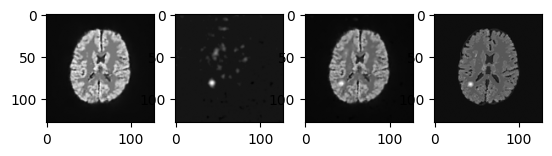

In [256]:

global_epochs = 100
inner_epochs = 50


for g_epoch in tqdm.tqdm(range(global_epochs)):

    for _ in range(inner_epochs):
        opt_c.zero_grad()
        loss = objective(c,r,y_measured)
        loss.backward()
        opt_c.step()



    for _ in range(inner_epochs):
        opt_r.zero_grad()
        loss = objective(c,r,y_measured)
        loss.backward()
        opt_r.step()

        '''with torch.no_grad():
            threshold = 1e-2
            r.data = torch.sign(r.data) * torch.clamp(torch.abs(r.data) - threshold, min=0)'''
    print(f'Global Epoch: {g_epoch}, Loss: {loss.item()}')

with torch.no_grad():
    plt.subplot(1,4,1)
    plt.imshow(decode_pca(c)[0][0].detach().cpu().numpy(), cmap='gray')
    plt.subplot(1,4,2)
    plt.imshow(r[0][0].detach().cpu().numpy(), cmap='gray')
    plt.subplot(1,4,3)
    plt.imshow(decode_pca(c)[0][0].detach().cpu().numpy() + r[0][0].detach().cpu().numpy(), cmap='gray')
    plt.subplot(1,4,4)
    plt.imshow(tum_im, cmap='gray')




Text(0.5, 1.0, 'Initial healthy reconstruction')

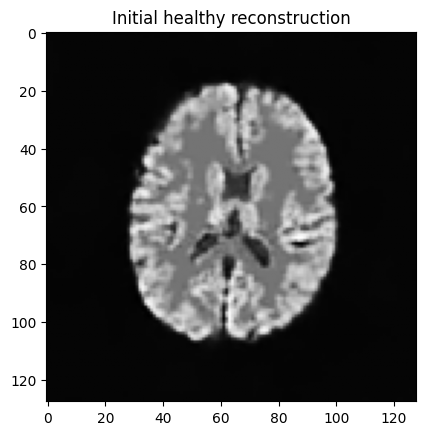

In [257]:
z_fbp = trained_ae.encode(fbp_recon)
c = pca.transform(z_fbp.detach().cpu().numpy())
c = torch.tensor(c[0], dtype=torch.float32, device=device)
recon = decode_pca(c)
plt.imshow(recon.detach().cpu().numpy()[0][0], cmap='gray')
plt.title('Initial healthy reconstruction')

In [21]:
tumor_images = []
healthy_images = []

for i in range(1, 21):
    csf = plt.imread(f'{i}_csf.gif')
    gry = plt.imread(f'{i}_gry.gif')
    wht = plt.imread(f'{i}_wht.gif')
    for _ in range(100):
        img, tum = create_tumor_image(csf, wht, gry)
        tumor_images.append(tum)
        healthy_images.append(img)

tumor_images = np.array(tumor_images)
healthy_images = np.array(healthy_images)
tumor_images = torch.tensor(tumor_images).float().to(device)
healthy_images = torch.tensor(healthy_images).float().to(device)
tumor_images = tumor_images.unsqueeze(1)

/tmp/ipykernel_2987/1468649695.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  tumor_images = torch.tensor(tumor_images).float().to(device)


In [44]:
tum_dataset = torch.utils.data.TensorDataset(tumor_images)
tum_loader = torch.utils.data.DataLoader(tum_dataset, batch_size=32, shuffle=True)

In [92]:
tumor_ae = AutoEncoder(latent_dim = 16).to(device)

def image_gradient(image):
    dx = image[:,:,:,1:] - image[:,:,:,:-1]
    dy = image[:,:,1:,:] - image[:,:,:-1,:]
    return dx, dy

def gradient_loss(reconstruction, x):
    dx, dy = image_gradient(reconstruction)
    dx_gt, dy_gt = image_gradient(x)
    loss = F.mse_loss(dx, dx_gt) + F.mse_loss(dy, dy_gt)
    return loss

def tumor_loss(reconstruction, x):
    w = 1 + 1000 * x
    return (w * (reconstruction - x)**2).sum()

tumor_opt = torch.optim.Adam(tumor_ae.parameters(), lr=1e-3)

In [93]:
epochs = 100
tumor_ae.train()
for epoch in tqdm.tqdm(range(epochs)):
    total_ae_loss = 0
    for batch in tum_loader:
        x = batch[0].to(device)
        reconstruction = tumor_ae(x)
        loss = tumor_loss(reconstruction, x)# + gradient_loss(reconstruction, x) + (1 - torchmetrics.functional.structural_similarity_index_measure(reconstruction, x))
        tumor_opt.zero_grad()
        loss.backward()
        tumor_opt.step()
        total_ae_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_ae_loss/len(loader)}")

  1%|          | 1/100 [00:01<02:00,  1.22s/it]

Epoch 1/100, Loss: 46633.731739831346


  2%|▏         | 2/100 [00:02<01:54,  1.17s/it]

Epoch 2/100, Loss: 33189.8951202877


  3%|▎         | 3/100 [00:03<01:52,  1.16s/it]

...

Epoch 98/100, Loss: 765.6157178121899


 99%|█████████▉| 99/100 [02:01<00:01,  1.27s/it]

Epoch 99/100, Loss: 692.5498565189422


100%|██████████| 100/100 [02:02<00:00,  1.22s/it]

Epoch 100/100, Loss: 681.7360670301649


In [50]:
torch.save(tumor_ae.state_dict(), 'tumor_ae_trained.pth')

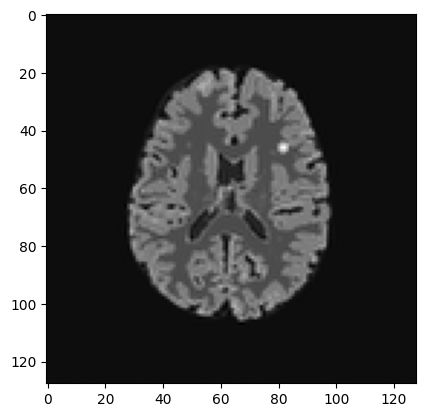

In [29]:
full_images = healthy_images + tumor_images
plt.imshow(full_images[0].cpu(), cmap='gray')

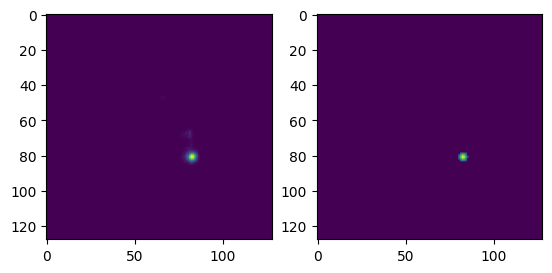

In [105]:
p = np.random.randint(0,2000)
tum_recon = tumor_ae(tumor_images[p].unsqueeze(0))
plt.subplot(1,2,1)
plt.imshow(tum_recon.detach().cpu().numpy()[0][0])
plt.subplot(1,2,2)
plt.imshow(tumor_images[p][0].detach().cpu())

In [111]:
tumor_ae.encode(tumor_images[0].unsqueeze(0)).shape

torch.Size([1, 16])

In [248]:
pca_mean = torch.tensor(pca.mean_, dtype=torch.float32, device=device)
pca_components = torch.tensor(pca.components_, dtype=torch.float32, device=device)

def decode_pca(c):
    z = pca_mean + pca_components.T @ c
    recon = trained_ae.decode(z.unsqueeze(0))
    return recon

def forward_model(c, r):
    x = decode_pca(c) + tumor_ae.decode(r.unsqueeze(0))
    x = torch.clamp(x, min=0.0)
    Ax = forward_project_torch(x)
    return 0.02 * Ax

def poisson_loss(Ax, y, I0 = 1e3):
    eps = 1e-8
    expected = I0 * torch.exp(-Ax)
    return (expected - y + y * torch.log((y + eps) / (expected + eps))).mean()
    #return (expected - y * torch.log(expected + eps)).mean()

def highfreq_reg(r):
    kernel = torch.tensor([
        [0,-1,0],
        [-1,4,-1],
        [0,-1,0]
    ], dtype=torch.float32, device=device).view(1,1,3,3)
    laplacian_pen = torch.sum(torch.conv2d(r,kernel, padding=1) ** 2)
    return laplacian_pen

def manifold_reg(c):
    return torch.sum(c ** 2)

def objective(c, r, y, lam_r = 0.05, lam_f = 0.005, lam_c = 0.05):
    Ax = forward_model(c, r)
    data_validity = poisson_loss(Ax, y)
    #sparsity = lam_r * torch.abs(r).sum()
    #laplacian_pen = lam_f * highfreq_reg(r)
    manifold_pen = lam_c * manifold_reg(c) + lam_r * manifold_reg(r)
    return  data_validity  + manifold_pen

y_measured = forward_project(tum_im, I0 = 1e3)
fbp_recon = iradon(-np.log(y_measured / 1e3 + 1e-8) / 0.02,theta=np.linspace(0,180,360,endpoint=False),circle=False, filter_name='hamming')
y_measured = torch.tensor(y_measured.T, dtype=torch.float32, device=device).unsqueeze(0)

fbp_recon = torch.tensor(fbp_recon, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
with torch.no_grad():
  z_fbp = trained_ae.encode(fbp_recon)
c = pca.transform(z_fbp.detach().cpu().numpy())
c = torch.tensor(c[0], dtype=torch.float32, device=device, requires_grad=True)
#c = torch.zeros(pca_components.shape[0], requires_grad=True, device=device)
r = torch.zeros((1,16), requires_grad=True, device=device)

opt_c = torch.optim.Adam([c], lr = 1e-4)
opt_r = torch.optim.Adam([r], lr = 1e-4)

In [249]:

global_epochs = 100
inner_epochs = 50


for g_epoch in tqdm.tqdm(range(global_epochs)):

    for _ in range(inner_epochs):
        opt_c.zero_grad()
        loss = objective(c,r,y_measured)
        loss.backward()
        opt_c.step()



    for _ in range(inner_epochs):
        opt_r.zero_grad()
        loss = objective(c,r,y_measured)
        loss.backward()
        opt_r.step()

        '''with torch.no_grad():
            threshold = 1e-2
            r.data = torch.sign(r.data) * torch.clamp(torch.abs(r.data) - threshold, min=0)'''
    print(f'Global Epoch: {g_epoch}, Loss: {loss.item()}')





  1%|          | 1/100 [00:00<00:46,  2.13it/s]

Global Epoch: 0, Loss: 7.748239994049072


  2%|▏         | 2/100 [00:00<00:45,  2.18it/s]

Global Epoch: 1, Loss: 7.7196245193481445


  3%|▎         | 3/100 [00:01<00:44,  2.20it/s]

...

Global Epoch: 97, Loss: 6.176970481872559


 99%|█████████▉| 99/100 [00:47<00:00,  1.79it/s]

Global Epoch: 98, Loss: 6.166298866271973


100%|██████████| 100/100 [00:47<00:00,  2.10it/s]

Global Epoch: 99, Loss: 6.155694961547852


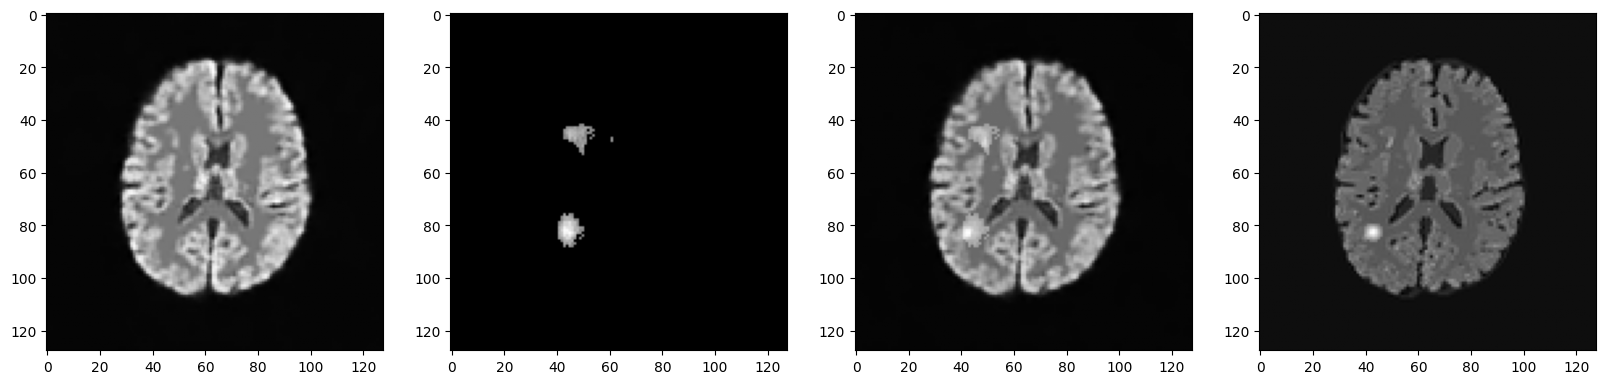

In [250]:

with torch.no_grad():
    healthy_recon = decode_pca(c)[0][0].detach().cpu().numpy()
    tumor_recon = tumor_ae.decode(r)[0][0].detach().cpu().numpy().copy()
    tumor_recon[tumor_recon < 0.2] = 0
    plt.figure(figsize=(20,5))
    plt.subplot(1,4,1)
    plt.imshow(healthy_recon, cmap='gray')
    plt.subplot(1,4,2)
    plt.imshow(tumor_recon, cmap='gray')
    plt.subplot(1,4,3)
    plt.imshow(healthy_recon + tumor_recon, cmap='gray')
    plt.subplot(1,4,4)
    plt.imshow(tum_im, cmap='gray')

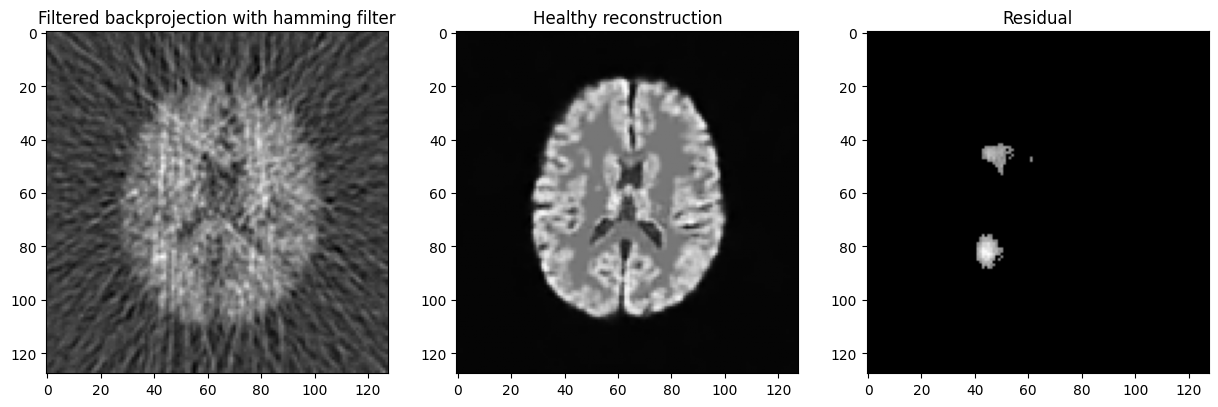

In [260]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title('Filtered backprojection with hamming filter')
plt.imshow(fbp_recon.cpu()[0][0], cmap='gray')
plt.subplot(1,3,2)
plt.title('Healthy reconstruction')
plt.imshow(healthy_recon, cmap='gray')
plt.subplot(1,3,3)
plt.title('Residual')
plt.imshow(tumor_recon,cmap='gray')

In [16]:
test_image = plt.imread('test image.gif')
h_test, t_test = create_tumor_image(test_image, test_image, test_image)

In [244]:
pca_mean = torch.tensor(pca.mean_, dtype=torch.float32, device=device)
pca_components = torch.tensor(pca.components_, dtype=torch.float32, device=device)

def decode_pca(c):
    z = pca_mean + pca_components.T @ c
    recon = trained_ae.decode(z.unsqueeze(0))
    return recon

def forward_model(c, r):
    x = decode_pca(c) + tumor_ae.decode(r.unsqueeze(0))
    x = torch.clamp(x, min=0.0)
    Ax = forward_project_torch(x)
    return 0.02 * Ax

def poisson_loss(Ax, y, I0 = 5e3):
    eps = 1e-8
    expected = I0 * torch.exp(-Ax)
    return (expected - y + y * torch.log((y + eps) / (expected + eps))).mean()
    #return (expected - y * torch.log(expected + eps)).mean()

def highfreq_reg(r):
    kernel = torch.tensor([
        [0,-1,0],
        [-1,4,-1],
        [0,-1,0]
    ], dtype=torch.float32, device=device).view(1,1,3,3)
    laplacian_pen = torch.sum(torch.conv2d(r,kernel, padding=1) ** 2)
    return laplacian_pen

def manifold_reg(c):
    return torch.sum(c ** 2)

def objective(c, r, y, lam_r = 0.05, lam_f = 0.005, lam_c = 0.05):
    Ax = forward_model(c, r)
    data_validity = poisson_loss(Ax, y)
    #sparsity = lam_r * torch.abs(r).sum()
    #laplacian_pen = lam_f * highfreq_reg(r)
    manifold_pen = lam_c * manifold_reg(c) + lam_r * manifold_reg(r)
    return 0.5* data_validity  + manifold_pen

y_measured = forward_project(h_test+t_test, I0 = 5e3)
fbp_recon = iradon(-np.log(y_measured / 5e3 + 1e-8) / 0.02,theta=np.linspace(0,180,360,endpoint=False),circle=False, filter_name='hamming')
y_measured = torch.tensor(y_measured.T, dtype=torch.float32, device=device).unsqueeze(0)

fbp_recon = torch.tensor(fbp_recon, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
with torch.no_grad():
  z_fbp = trained_ae.encode(fbp_recon)
c = pca.transform(z_fbp.detach().cpu().numpy())
c = torch.tensor(c[0], dtype=torch.float32, device=device, requires_grad=True)
#c = torch.zeros(pca_components.shape[0], requires_grad=True, device=device)
r = torch.zeros((1,16), requires_grad=True, device=device)

opt_c = torch.optim.Adam([c], lr = 1e-4)
opt_r = torch.optim.Adam([r], lr = 1e-4)

In [245]:

global_epochs = 100
inner_epochs = 50


for g_epoch in tqdm.tqdm(range(global_epochs)):

    for _ in range(inner_epochs):
        opt_c.zero_grad()
        loss = objective(c,r,y_measured)
        loss.backward()
        opt_c.step()



    for _ in range(inner_epochs):
        opt_r.zero_grad()
        loss = objective(c,r,y_measured)
        loss.backward()
        opt_r.step()

        '''with torch.no_grad():
            threshold = 1e-2
            r.data = torch.sign(r.data) * torch.clamp(torch.abs(r.data) - threshold, min=0)'''
    print(f'Global Epoch: {g_epoch}, Loss: {loss.item()}')





  1%|          | 1/100 [00:00<00:54,  1.83it/s]

Global Epoch: 0, Loss: 22.08021354675293


  2%|▏         | 2/100 [00:01<00:48,  2.02it/s]

Global Epoch: 1, Loss: 21.731210708618164


  3%|▎         | 3/100 [00:01<00:45,  2.13it/s]

...

Global Epoch: 97, Loss: 9.935586929321289


 99%|█████████▉| 99/100 [00:48<00:00,  2.10it/s]

Global Epoch: 98, Loss: 9.89222240447998


100%|██████████| 100/100 [00:48<00:00,  2.06it/s]

Global Epoch: 99, Loss: 9.849720001220703


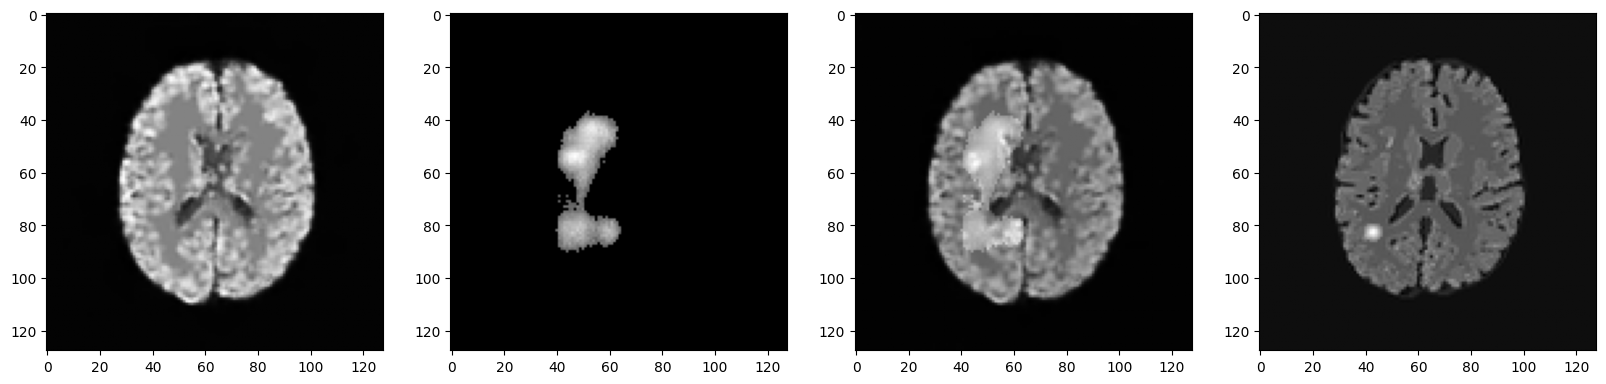

In [246]:

with torch.no_grad():
    healthy_recon = decode_pca(c)[0][0].detach().cpu().numpy()
    tumor_recon = tumor_ae.decode(r)[0][0].detach().cpu().numpy().copy()
    tumor_recon[tumor_recon < 0.2] = 0
    plt.figure(figsize=(20,5))
    plt.subplot(1,4,1)
    plt.imshow(healthy_recon, cmap='gray')
    plt.subplot(1,4,2)
    plt.imshow(tumor_recon, cmap='gray')
    plt.subplot(1,4,3)
    plt.imshow(healthy_recon + tumor_recon, cmap='gray')
    plt.subplot(1,4,4)
    plt.imshow(tum_im, cmap='gray')

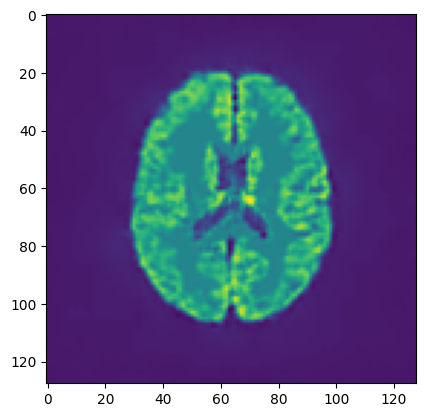

In [237]:
variation = np.random.randn(40) * 0.5
latent_vector = pca.inverse_transform(variation)
generated_image = trained_ae.decode(torch.tensor(latent_vector, dtype=torch.float32, device=device).unsqueeze(0))
plt.imshow(generated_image.detach().cpu()[0][0])

In [240]:
new_dataset = []
for _ in range(10000):
  variation = np.random.randn(40) * 0.5
  latent_vector = pca.inverse_transform(variation)
  generated_image = trained_ae.decode(torch.tensor(latent_vector, dtype=torch.float32, device=device).unsqueeze(0)).detach().cpu().numpy()
  new_dataset.append(generated_image)
new_dataset = np.array(new_dataset)
new_dataset = torch.tensor(new_dataset).float().to(device).unsqueeze(1)
new_dataset = torch.utils.data.TensorDataset(tumor_images)
new_loader = torch.utils.data.DataLoader(tum_dataset, batch_size=32, shuffle=True)


In [241]:
ae = AutoEncoder(latent_dim=128).to(device)

ae_optimizer = torch.optim.Adam(ae.parameters(), lr = 1e-3)

epochs = 100
ae.train()
for epoch in tqdm.tqdm(range(epochs)):
    total_ae_loss = 0
    for batch in new_loader:
        x = batch[0].to(device)
        reconstruction = ae(x)
        loss = F.mse_loss(reconstruction, x) + gradient_loss(reconstruction, x) + (1 - torchmetrics.functional.structural_similarity_index_measure(reconstruction, x))
        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()
        total_ae_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_ae_loss/len(loader)}")

  0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(
  1%|          | 1/100 [00:01<03:10,  1.93s/it]

Epoch 1/100, Loss: 0.11034952386444996


  2%|▏         | 2/100 [00:03<03:04,  1.88s/it]

Epoch 2/100, Loss: 0.00838906162728866


  3%|▎         | 3/100 [00:05<03:00,  1.87s/it]

...

Epoch 98/100, Loss: 0.008388160099644982


 99%|█████████▉| 99/100 [02:40<00:01,  1.60s/it]

Epoch 99/100, Loss: 0.008384277083216206


100%|██████████| 100/100 [02:42<00:00,  1.62s/it]

Epoch 100/100, Loss: 0.008384049071797304


In [242]:
disc = LatentDiscriminator(latent_dim=128).to(device)

aae_optimizer = torch.optim.Adam(ae.parameters(), lr = 1e-4)
disc_optimizer = torch.optim.Adam(disc.parameters(), lr = 1e-4)

aae_epochs = 100
ae.train()
disc.train()


for epoch in tqdm.tqdm(range(epochs)):
  total_rec = 0
  total_adv = 0
  total_disc = 0
  for batch in new_loader:
    x = batch[0].float().to(device)
    z_real = torch.randn(x.size(0), 128, device=device)
    z_fake = ae.encode(x).detach()

    pred_real = disc(z_real)
    pred_fake = disc(z_fake)

    label_real = torch.ones_like(pred_real)
    label_fake = torch.zeros_like(pred_fake)

    loss_real = F.binary_cross_entropy(pred_real, label_real)
    loss_fake = F.binary_cross_entropy(pred_fake, label_fake)
    disc_loss = loss_real + loss_fake
    disc_optimizer.zero_grad()
    disc_loss.backward()
    disc_optimizer.step()

    for p in disc.parameters():
      p.requires_grad = False
    z = ae.encode(x)
    reconstruction = ae.decode(z)
    rec_loss = F.mse_loss(reconstruction, x) + gradient_loss(reconstruction, x) + (1 - torchmetrics.functional.structural_similarity_index_measure(reconstruction, x))
    pred_fake = disc(z)
    adv_loss = F.binary_cross_entropy(pred_fake, torch.ones_like(pred_fake))
    ae_loss = rec_loss + 0.01 * adv_loss
    aae_optimizer.zero_grad()
    ae_loss.backward()
    aae_optimizer.step()

    for p in disc.parameters():
      p.requires_grad = True

    total_rec += rec_loss.item()
    total_adv += adv_loss.item()
    total_disc += disc_loss.item()

  print(f"Epoch {epoch + 1}, rec_loss {total_rec / len(loader)}, adv_loss {total_adv/len(loader)}, disc_loss {total_disc / len(loader)}")


  1%|          | 1/100 [00:01<03:04,  1.86s/it]

Epoch 1, rec_loss 0.008387380530909887, adv_loss 4.616049876288762, disc_loss 92.62895687515774


  2%|▏         | 2/100 [00:03<02:55,  1.79s/it]

Epoch 2, rec_loss 0.008387186638419591, adv_loss 0.0, disc_loss 100.31174577985492


  3%|▎         | 3/100 [00:05<02:52,  1.78s/it]

...

Epoch 98, rec_loss 0.008384135743928335, adv_loss 0.0, disc_loss 100.00001562209357


 99%|█████████▉| 99/100 [02:58<00:01,  1.79s/it]

Epoch 99, rec_loss 0.00838637255900909, adv_loss 0.0, disc_loss 100.00001586429657


100%|██████████| 100/100 [03:00<00:00,  1.81s/it]

Epoch 100, rec_loss 0.008386904654640055, adv_loss 0.0, disc_loss 100.00001598539806


/tmp/ipykernel_2987/1721986319.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).unsqueeze(0).to(device)


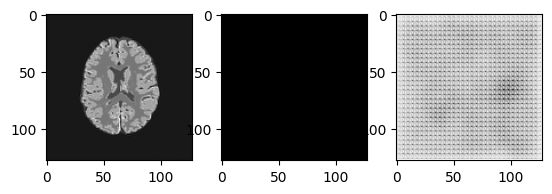

In [243]:
ae.eval()
disc.eval()
with torch.no_grad():
  x = images[np.random.randint(0, len(images))]
  x = torch.tensor(x).unsqueeze(0).to(device)
  recon = ae(x)
  z = torch.randn(1, 128, device=device)
  gen = ae.decode(z).cpu()
  plt.subplot(1,3,1)
  plt.imshow(x.cpu()[0][0], cmap='gray')
  plt.subplot(1,3,2)
  plt.imshow(recon.cpu()[0][0], cmap='gray')
  plt.subplot(1,3,3)
  plt.imshow(gen[0][0], cmap='gray')

In [17]:
pca_mean = torch.tensor(pca.mean_, dtype=torch.float32, device=device)
pca_components = torch.tensor(pca.components_, dtype=torch.float32, device=device)

def decode_pca(c):
    z = pca_mean + pca_components.T @ c
    recon = trained_ae.decode(z.unsqueeze(0))
    return recon

def forward_model(c, res):
    x = decode_pca(c) + res
    x = torch.clamp(x, min=0.0)
    Ax = forward_project_torch(x)
    return 0.02 * Ax

def poisson_loss(Ax, y, I0 = 1e3):
    eps = 1e-8
    expected = I0 * torch.exp(-Ax)
    return (expected - y + y * torch.log((y + eps) / (expected + eps))).mean()
    #return (expected - y * torch.log(expected + eps)).mean()

def highfreq_reg(r):
    kernel = torch.tensor([
        [0,-1,0],
        [-1,4,-1],
        [0,-1,0]
    ], dtype=torch.float32, device=device).view(1,1,3,3)
    laplacian_pen = torch.sum(torch.conv2d(r,kernel, padding=1) ** 2)
    return laplacian_pen

def manifold_reg(c):
    return torch.sum(c ** 2)

def objective(c, r, y, lam_r = 0.001, lam_f = 0.005, lam_c = 0.005):
    Ax = forward_model(c, r)
    data_validity = poisson_loss(Ax, y)
    sparsity = lam_r * torch.abs(r).sum()
    laplacian_pen = lam_f * highfreq_reg(r)
    manifold_pen = lam_c * manifold_reg(c)
    return data_validity + sparsity + laplacian_pen + manifold_pen

y_measured = forward_project(h_test+t_test, I0 = 1e3)
fbp_recon = iradon(-np.log(y_measured / 1e3 + 1e-8) / 0.02,theta=np.linspace(0,180,360,endpoint=False),circle=False, filter_name='hamming')
y_measured = torch.tensor(y_measured.T, dtype=torch.float32, device=device).unsqueeze(0)

fbp_recon = torch.tensor(fbp_recon, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
with torch.no_grad():
  z_fbp = trained_ae.encode(fbp_recon)
c = pca.transform(z_fbp.detach().cpu().numpy())
c = torch.tensor(c[0], dtype=torch.float32, device=device, requires_grad=True)
#c = torch.zeros(pca_components.shape[0], requires_grad=True, device=device)
r = torch.zeros((1,1,128,128), requires_grad=True, device=device)

opt_c = torch.optim.Adam([c], lr = 1e-3)
opt_r = torch.optim.Adam([r], lr = 1e-4)

  1%|          | 1/100 [00:01<02:05,  1.27s/it]

Global Epoch: 0, Loss: 12.931843757629395


  2%|▏         | 2/100 [00:01<01:21,  1.21it/s]

Global Epoch: 1, Loss: 12.437865257263184


  3%|▎         | 3/100 [00:02<01:06,  1.45it/s]

...

Global Epoch: 97, Loss: 9.289383888244629


 99%|█████████▉| 99/100 [00:38<00:00,  2.81it/s]

Global Epoch: 98, Loss: 9.28782844543457


100%|██████████| 100/100 [00:39<00:00,  2.56it/s]

Global Epoch: 99, Loss: 9.286355972290039


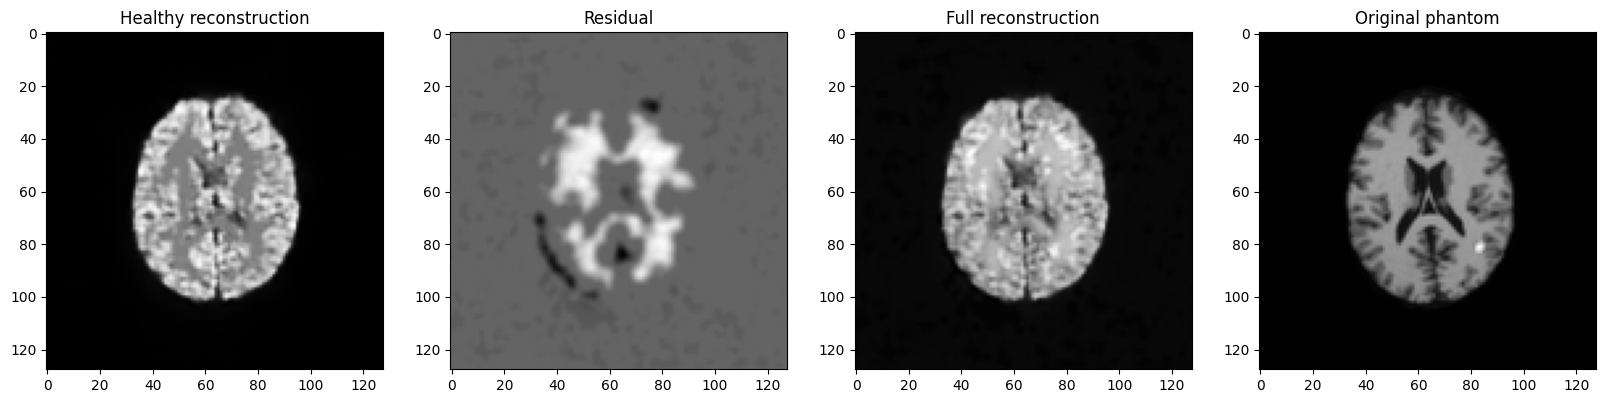

In [18]:

global_epochs = 100
inner_epochs = 50


for g_epoch in tqdm.tqdm(range(global_epochs)):

    for _ in range(inner_epochs):
        opt_c.zero_grad()
        loss = objective(c,r,y_measured)
        loss.backward()
        opt_c.step()



    for _ in range(inner_epochs):
        opt_r.zero_grad()
        loss = objective(c,r,y_measured)
        loss.backward()
        opt_r.step()

        '''with torch.no_grad():
            threshold = 1e-2
            r.data = torch.sign(r.data) * torch.clamp(torch.abs(r.data) - threshold, min=0)'''
    print(f'Global Epoch: {g_epoch}, Loss: {loss.item()}')

with torch.no_grad():
    plt.figure(figsize=(20,5))
    plt.subplot(1,4,1)
    plt.title('Healthy reconstruction')
    plt.imshow(decode_pca(c)[0][0].detach().cpu().numpy(), cmap='gray')
    plt.subplot(1,4,2)
    plt.imshow(r[0][0].detach().cpu().numpy(), cmap='gray')
    plt.title('Residual')
    plt.subplot(1,4,3)
    plt.imshow(decode_pca(c)[0][0].detach().cpu().numpy() + r[0][0].detach().cpu().numpy(), cmap='gray')
    plt.title('Full reconstruction')
    plt.subplot(1,4,4)
    plt.imshow(h_test + t_test, cmap='gray')
    plt.title('Original phantom')




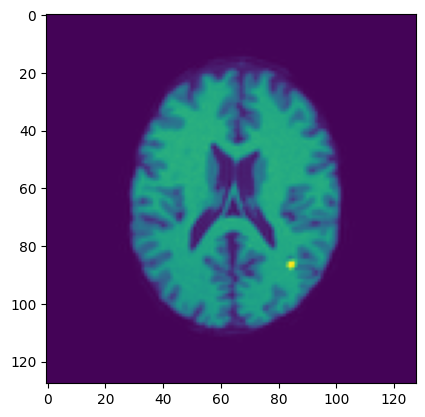

In [20]:
plt.imshow(h_test + t_test)

In [70]:
pca_mean = torch.tensor(pca.mean_, dtype=torch.float32, device=device)
pca_components = torch.tensor(pca.components_, dtype=torch.float32, device=device)

global_epochs = 100
inner_epochs = 50

def decode_pca(c):
    z = pca_mean + pca_components.T @ c
    recon = trained_ae.decode(z.unsqueeze(0))
    return recon

def forward_model(c, res):
    x = decode_pca(c) + res
    x = torch.clamp(x, min=0.0)
    Ax = forward_project_torch(x)
    return 0.02 * Ax

def poisson_loss(Ax, y, I0 = 1e3):
    eps = 1e-8
    expected = I0 * torch.exp(-Ax)
    return (expected - y + y * torch.log((y + eps) / (expected + eps))).mean()
    #return (expected - y * torch.log(expected + eps)).mean()

def highfreq_reg(r):
    kernel = torch.tensor([
        [0,-1,0],
        [-1,4,-1],
        [0,-1,0]
    ], dtype=torch.float32, device=device).view(1,1,3,3)
    laplacian_pen = torch.sum(torch.conv2d(r,kernel, padding=1) ** 2)
    return laplacian_pen

def manifold_reg(c):
    return torch.sum(c ** 2)

def objective(c, r, y, lam_r = 0.01, lam_f = 0.05, lam_c = 0.005, I0 = 1e3):
    Ax = forward_model(c, r)
    data_validity = poisson_loss(Ax, y, I0 = I0)
    sparsity = lam_r * torch.abs(r).sum()
    laplacian_pen = lam_f * highfreq_reg(r)
    manifold_pen = lam_c * manifold_reg(c)
    return data_validity + sparsity + laplacian_pen + manifold_pen

fbp_images = []
model_images = []
test_images = []
for intensity in [ 1e2, 1e3, 1e4]:
  for _ in range(3):
    h_test, t_test = create_tumor_image(test_image, test_image, test_image)
    test_images.append(h_test + t_test)
    y_measured = forward_project(h_test+t_test, I0 = intensity)
    fbp_recon = iradon(-np.log(y_measured / intensity + 1e-8) / 0.02,theta=np.linspace(0,180,360,endpoint=False),circle=False, filter_name='hamming')
    y_measured = torch.tensor(y_measured.T, dtype=torch.float32, device=device).unsqueeze(0)
    fbp_images.append(fbp_recon)
    fbp_recon = torch.tensor(fbp_recon, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
      z_fbp = trained_ae.encode(fbp_recon)
    c = pca.transform(z_fbp.detach().cpu().numpy())
    c = torch.tensor(c[0], dtype=torch.float32, device=device, requires_grad=True)
    #c = torch.zeros(pca_components.shape[0], requires_grad=True, device=device)
    r = torch.zeros((1,1,128,128), requires_grad=True, device=device)

    opt_c = torch.optim.Adam([c], lr = 1e-4)
    opt_r = torch.optim.Adam([r], lr = 1e-4)
    for g_epoch in tqdm.tqdm(range(global_epochs)):

      for _ in range(inner_epochs):
          opt_c.zero_grad()
          loss = objective(c,r,y_measured, I0 = intensity)
          loss.backward()
          opt_c.step()



      for _ in range(inner_epochs):
          opt_r.zero_grad()
          loss = objective(c,r,y_measured)
          loss.backward()
          opt_r.step()
    model_images.append(decode_pca(c)[0][0].detach().cpu().numpy() + r[0][0].detach().cpu().numpy())



100%|██████████| 100/100 [00:35<00:00,  2.84it/s]


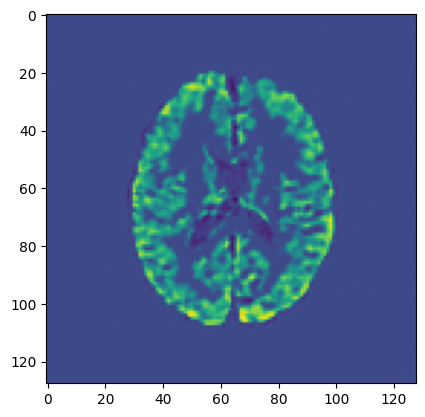

In [40]:
plt.imshow(model_images[6])

In [35]:
def compute_psnr(original, reconstructed):
    return skimage.metrics.peak_signal_noise_ratio(original, reconstructed, data_range=1.0)

def compute_ssim(original, reconstructed):
    return skimage.metrics.structural_similarity(original, reconstructed, data_range=1.0)

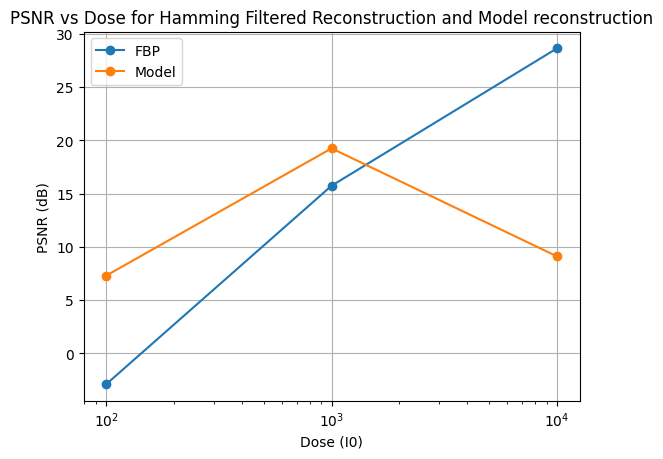

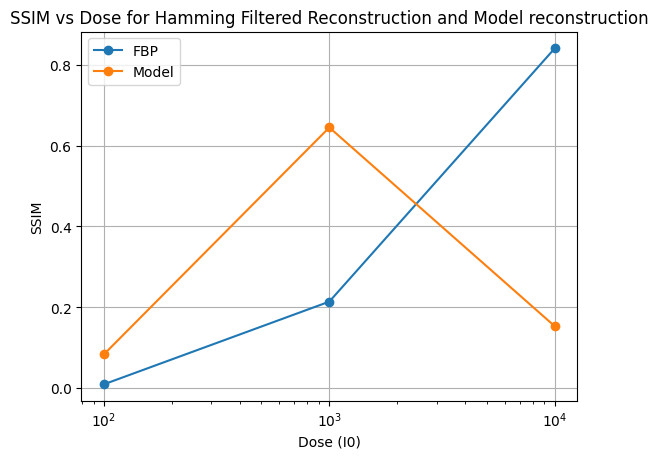

In [45]:
fbp_psnr = []
model_psnr = []
fbp_ssim = []
model_ssim = []
for i in range(3):
  fbp_c_psnr = []
  fbp_c_ssim = []
  model_c_psnr =[]
  model_c_ssim = []
  for j in range(3):
    fbp_im = fbp_images[i * 3 + j]
    model_im = model_images[i*3+j]
    test_im = test_images[i*3+j]

    fbp_c_psnr.append(compute_psnr(test_im,fbp_im))
    fbp_c_ssim.append(compute_ssim(test_im,fbp_im))
    model_c_psnr.append(compute_psnr(test_im, model_im))
    model_c_ssim.append(compute_ssim(test_im, model_im))
  fbp_psnr.append(np.mean(fbp_c_psnr))
  fbp_ssim.append(np.mean(fbp_c_ssim))
  model_psnr.append(np.mean(model_c_psnr))
  model_ssim.append(np.mean(model_c_ssim))

plt.plot([1e2, 1e3, 1e4], fbp_psnr, marker='o', label = 'FBP')
plt.plot([1e2, 1e3, 1e4], model_psnr, marker='o', label = 'Model')
plt.xscale('log')
plt.xlabel('Dose (I0)')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs Dose for Hamming Filtered Reconstruction and Model reconstruction')
plt.grid()
plt.legend()
plt.show()
plt.plot([1e2, 1e3, 1e4], fbp_ssim, marker='o', label = 'FBP')
plt.plot([1e2, 1e3, 1e4], model_ssim, marker='o', label='Model')
plt.xscale('log')
plt.xlabel('Dose (I0)')
plt.ylabel('SSIM')
plt.title('SSIM vs Dose for Hamming Filtered Reconstruction and Model reconstruction')
plt.grid()
plt.legend()
plt.show()


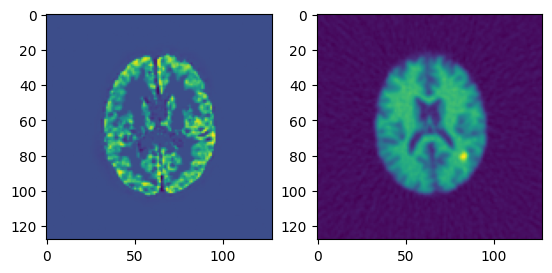

In [48]:
plt.subplot(1,2,1)
plt.imshow(model_images[7])
plt.subplot(1,2,2)
plt.imshow(fbp_images[7])

In [67]:
pca_mean = torch.tensor(pca.mean_, dtype=torch.float32, device=device)
pca_components = torch.tensor(pca.components_, dtype=torch.float32, device=device)

global_epochs = 100
inner_epochs = 50

def decode_pca(c):
    z = pca_mean + pca_components.T @ c
    recon = trained_ae.decode(z.unsqueeze(0))
    return recon

def forward_model(c, res):
    x = decode_pca(c) + res
    x = torch.clamp(x, min=0.0)
    Ax = forward_project_torch(x)
    return 0.02 * Ax

def poisson_loss(Ax, y, I0 = 1e3):
    eps = 1e-8
    expected = I0 * torch.exp(-Ax)
    return (expected - y + y * torch.log((y + eps) / (expected + eps))).mean()
    #return (expected - y * torch.log(expected + eps)).mean()

def highfreq_reg(r):
    kernel = torch.tensor([
        [0,-1,0],
        [-1,4,-1],
        [0,-1,0]
    ], dtype=torch.float32, device=device).view(1,1,3,3)
    laplacian_pen = torch.sum(torch.conv2d(r,kernel, padding=1) ** 2)
    return laplacian_pen

def manifold_reg(c):
    return torch.sum(c ** 2)

def objective(c, r, y, lam_r = 0.01, lam_f = 0.05, lam_c = 0.05, I0 = 1e3):
    Ax = forward_model(c, r)
    data_validity = poisson_loss(Ax, y, I0 = I0)
    sparsity = lam_r * torch.abs(r).sum()
    laplacian_pen = lam_f * highfreq_reg(r)
    manifold_pen = lam_c * manifold_reg(c)
    return data_validity + sparsity + laplacian_pen + manifold_pen

fbp_images = []
model_images = []
test_images = []
for intensity in [ 1e2, 1e3, 1e4]:
  for _ in range(3):
    i = np.random.randint(1,21)
    csf = plt.imread(f'{i}_csf.gif')
    gry = plt.imread(f'{i}_gry.gif')
    wht = plt.imread(f'{i}_wht.gif')
    healthy_test, tumor_test = create_tumor_image(csf,wht,gry)
    test_images.append(healthy_test + tumor_test)
    y_measured = forward_project(healthy_test+tumor_test, I0 = intensity)
    fbp_recon = iradon(-np.log(y_measured / intensity + 1e-8) / 0.02,theta=np.linspace(0,180,360,endpoint=False),circle=False, filter_name='hamming')
    y_measured = torch.tensor(y_measured.T, dtype=torch.float32, device=device).unsqueeze(0)
    fbp_images.append(fbp_recon)
    fbp_recon = torch.tensor(fbp_recon, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
      z_fbp = trained_ae.encode(fbp_recon)
    c = pca.transform(z_fbp.detach().cpu().numpy())
    c = torch.tensor(c[0], dtype=torch.float32, device=device, requires_grad=True)
    #c = torch.zeros(pca_components.shape[0], requires_grad=True, device=device)
    r = torch.zeros((1,1,128,128), requires_grad=True, device=device)

    opt_c = torch.optim.Adam([c], lr = 1e-4)
    opt_r = torch.optim.Adam([r], lr = 1e-4)
    for g_epoch in tqdm.tqdm(range(global_epochs)):

      for _ in range(inner_epochs):
          opt_c.zero_grad()
          loss = objective(c,r,y_measured, I0 = intensity)
          loss.backward()
          opt_c.step()



      for _ in range(inner_epochs):
          opt_r.zero_grad()
          loss = objective(c,r,y_measured)
          loss.backward()
          opt_r.step()
    healthy_recon = decode_pca(c)[0][0].detach().cpu().numpy()
    tumor_recon = r[0][0].detach().cpu().numpy()
    tumor_recon[tumor_recon < 0.2] = 0
    model_images.append(healthy_recon + tumor_recon)



100%|██████████| 100/100 [00:35<00:00,  2.82it/s]


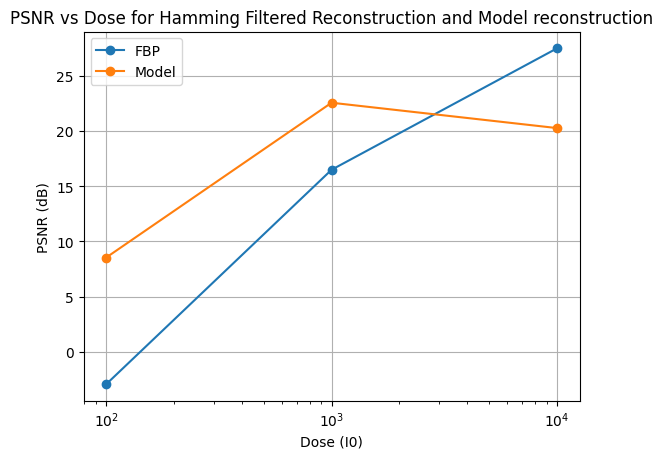

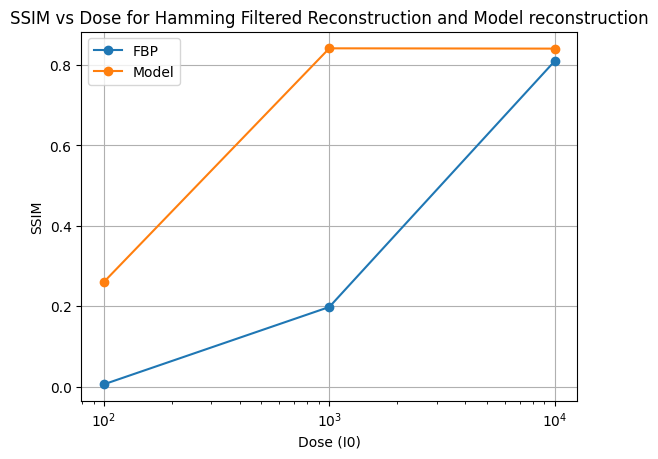

In [68]:
fbp_psnr = []
model_psnr = []
fbp_ssim = []
model_ssim = []
for i in range(3):
  fbp_c_psnr = []
  fbp_c_ssim = []
  model_c_psnr =[]
  model_c_ssim = []
  for j in range(3):
    fbp_im = fbp_images[i * 3 + j]
    model_im = model_images[i*3+j]
    test_im = test_images[i*3+j]

    fbp_c_psnr.append(compute_psnr(test_im,fbp_im))
    fbp_c_ssim.append(compute_ssim(test_im,fbp_im))
    model_c_psnr.append(compute_psnr(test_im, model_im))
    model_c_ssim.append(compute_ssim(test_im, model_im))
  fbp_psnr.append(np.mean(fbp_c_psnr))
  fbp_ssim.append(np.mean(fbp_c_ssim))
  model_psnr.append(np.mean(model_c_psnr))
  model_ssim.append(np.mean(model_c_ssim))

plt.plot([1e2, 1e3, 1e4], fbp_psnr, marker='o', label = 'FBP')
plt.plot([1e2, 1e3, 1e4], model_psnr, marker='o', label = 'Model')
plt.xscale('log')
plt.xlabel('Dose (I0)')
plt.ylabel('PSNR (dB)')
plt.title('PSNR vs Dose for Hamming Filtered Reconstruction and Model reconstruction')
plt.grid()
plt.legend()
plt.show()
plt.plot([1e2, 1e3, 1e4], fbp_ssim, marker='o', label = 'FBP')
plt.plot([1e2, 1e3, 1e4], model_ssim, marker='o', label='Model')
plt.xscale('log')
plt.xlabel('Dose (I0)')
plt.ylabel('SSIM')
plt.title('SSIM vs Dose for Hamming Filtered Reconstruction and Model reconstruction')
plt.grid()
plt.legend()
plt.show()


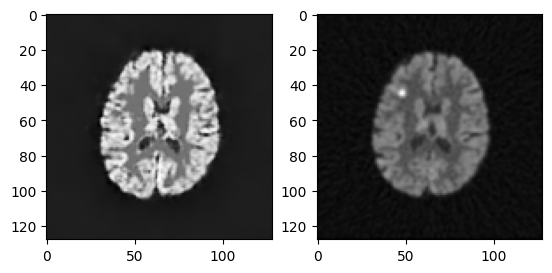

In [69]:
plt.subplot(1,2,1)
plt.imshow(model_images[8], cmap='gray')
plt.subplot(1,2,2)
plt.imshow(fbp_images[8], cmap='gray')

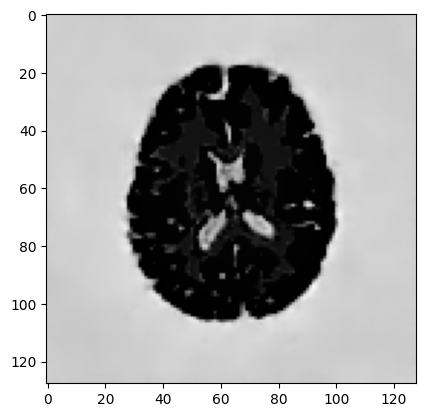

In [66]:
plt.imshow(r.detach().cpu().numpy()[0][0], cmap='gray')